# Task 3 - Data Visualization Dashboard

## CodSoft Data Analytics Internship

## 1. Objective
The primary objective of this project is to transform the cleaned retail sales dataset into a series of highly professional, self-explanatory, and insightful data visualizations using **Matplotlib** and **Seaborn**. The visualizations will cover different analytical angles:
- **Comparisons:** Compare categorical segments using bar charts.
- **Trends:** Chart changes in sales revenue chronologically over monthly intervals.
- **Proportions:** Show parts-of-a-whole contribution using pie charts.
- **Distributions:** Display shape, spread, and skewness using histograms.
- **Relationships:** Inspect interactions and correlations between columns using scatter plots and heatmaps.

Additionally, we will export a Power BI-ready dataset (`dashboard/dashboard_data.csv`) with derived temporal dimensions to prepare for the interactive dashboard.

## 2. Dataset Description
The dataset contains transactional retail data. The main variables investigated include:
- **`order_id`**: Unique order ID.
- **`order_date`**: Calendar date of the purchase.
- **`customer_id`**: Unique customer ID.
- **`product_category`**: Category of items ordered.
- **`region`**: Geographical sales region.
- **`quantity`**: Items per transaction.
- **`unit_price`**: Price per item.
- **`discount`**: Percentage discount rate.
- **`payment_method`**: Method used to pay.
- **`delivery_days`**: Operational delivery duration.
- **`customer_rating`**: Customer satisfaction score.
- **`revenue`**: Total transaction value.

## 3. Import Libraries
We import Pandas, NumPy, Matplotlib, and Seaborn. We also ensure that output directories `charts` and `dashboard` exist.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create directories if they do not exist
os.makedirs('charts', exist_ok=True)
os.makedirs('dashboard', exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

## 4. Load Dataset
Load the preprocessed dataset `Data/cleaned_data.csv` and inspect its shape and first few rows.

In [2]:
# Load cleaned dataset
df = pd.read_csv('Data/cleaned_data.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 12)


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## 5. Visualization Preparation
Convert the `order_date` column to proper datetime objects for temporal grouping.

In [3]:
# Parse date column
df['order_date'] = pd.to_datetime(df['order_date'])
print("order_date type:", df['order_date'].dtype)

order_date type: datetime64[ns]


## 6. Bar Chart: Revenue by Product Category
We group transactions by `product_category` and sum the `revenue` to compare category-wise sales performance.

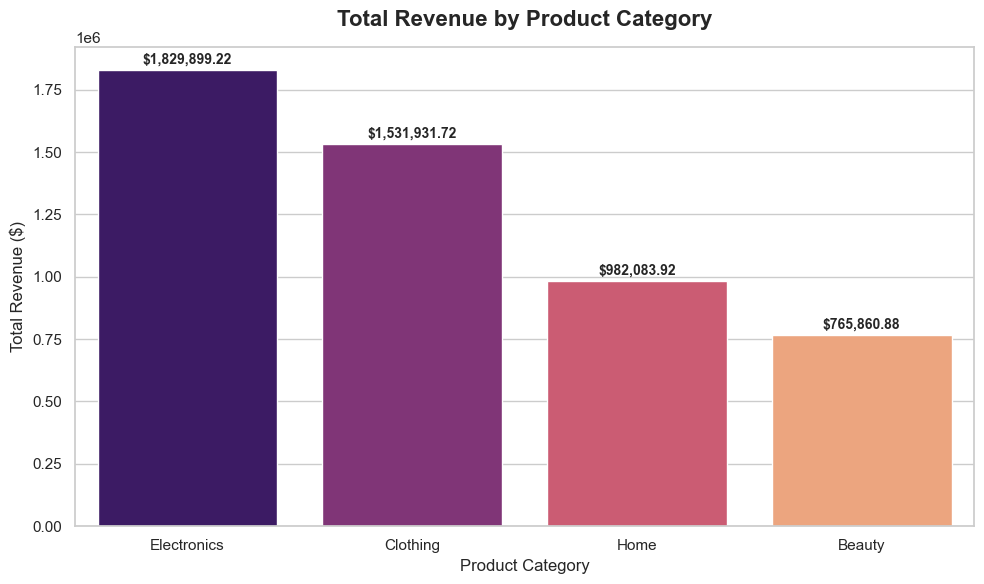

In [4]:
cat_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='magma')
plt.title('Total Revenue by Product Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Add data value labels on top of the bars
for i, v in enumerate(cat_revenue.values):
    plt.text(i, v + 25000, f"${v:,.2f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/bar_chart.png', bbox_inches='tight', dpi=300)
plt.show()

### Insight
**Electronics** contributes the largest share of sales revenue, yielding **$1,829,899.22** (35.8% of total sales). Clothing is second with **$1,531,931.72** (30.0%), followed by Home ($982,083.92) and Beauty ($765,860.88). Electronics and Clothing are the primary business revenue engines, together making up over 65% of the total revenue.

## 7. Line Chart: Monthly Sales Revenue Trend
We group the transactions by month chronologically to see sales trends over the period.

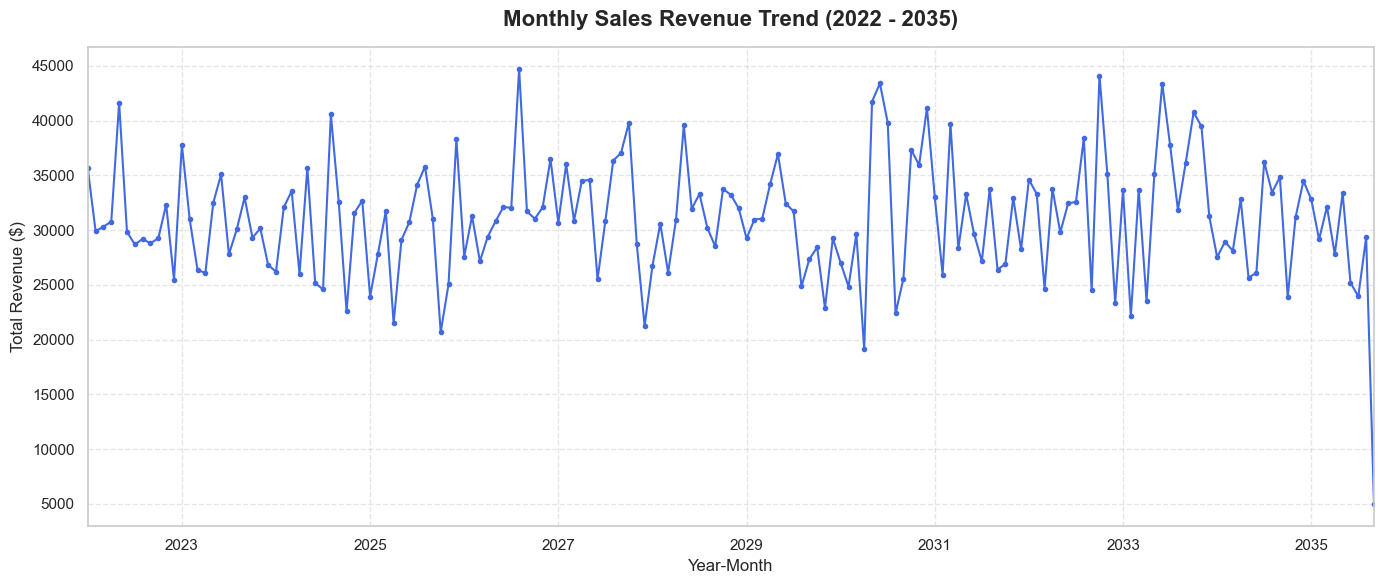

In [5]:
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('year_month')['revenue'].sum()

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line', marker='.', color='royalblue', linewidth=1.5)
plt.title('Monthly Sales Revenue Trend (2022 - 2035)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('charts/line_chart.png', bbox_inches='tight', dpi=300)
plt.show()

### Insight
Monthly sales exhibit a highly stable **stationary demand pattern**, fluctuating constantly in the range of **$20,000 to $45,000** monthly. There is no major long-term growth or decline trend, indicating stable, predictable order fulfillment cycles over the entire 13-year span.

## 8. Pie Chart: Proportions of Transactions by Payment Method
We show the percentage share of each payment method to evaluate customer preferences.

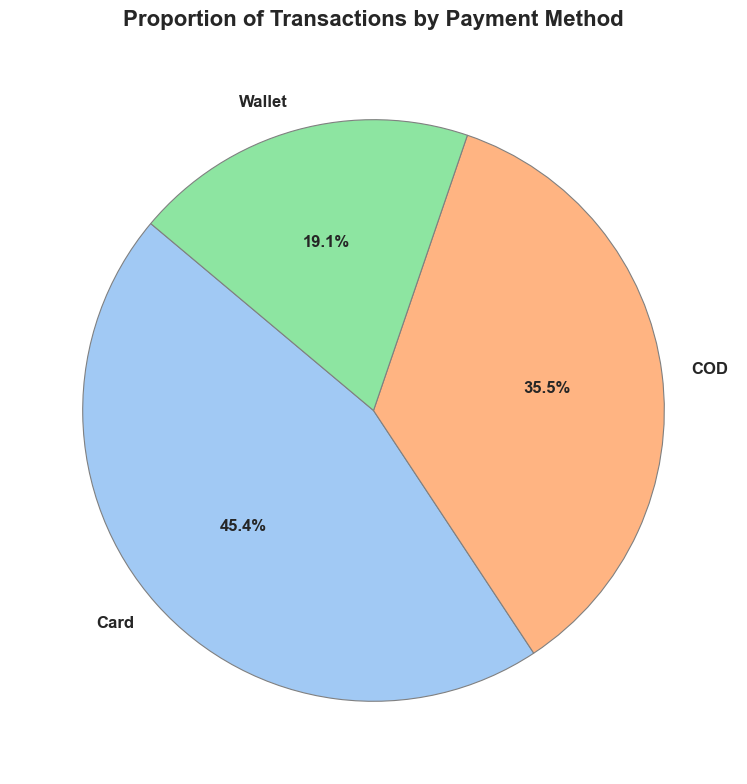

In [6]:
pay_counts = df['payment_method'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('pastel'), textprops={'fontsize': 12, 'weight': 'bold'}, 
        wedgeprops={'edgecolor': 'gray', 'linewidth': 0.8})
plt.title('Proportion of Transactions by Payment Method', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('charts/pie_chart.png', bbox_inches='tight', dpi=300)
plt.show()

### Insight
**Card** is the dominant payment option chosen by customers, accounting for **45.4%** of all transactions. Cash on Delivery (COD) accounts for **35.5%**, while digital Wallets account for **19.1%**.

## 9. Histogram: Distribution of Transaction Revenue
We display the distribution of sales values using a histogram, overlaying the mean and median.

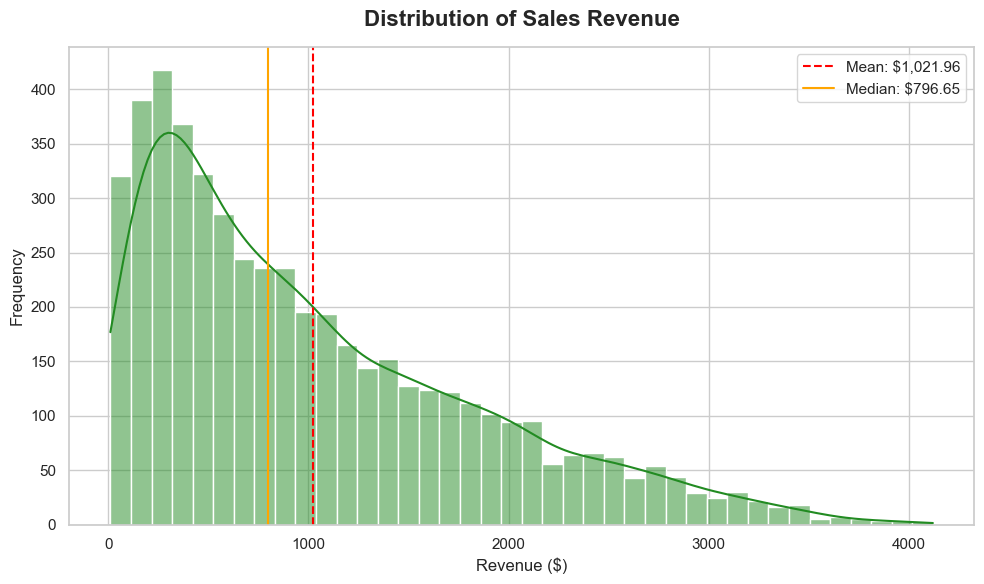

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'], kde=True, color='forestgreen', bins=40)
plt.axvline(df['revenue'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: ${df['revenue'].mean():,.2f}")
plt.axvline(df['revenue'].median(), color='orange', linestyle='-', linewidth=1.5, label=f"Median: ${df['revenue'].median():,.2f}")
plt.title('Distribution of Sales Revenue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('charts/histogram.png', bbox_inches='tight', dpi=300)
plt.show()

### Insight
The transaction revenue has a **moderately right-skewed distribution** (skewness = 1.00), where the median revenue is **$796.65** and the mean is **$1,021.96**. This shape is caused by a concentration of low-to-medium-value orders, with a long tail of high-value transactions extending past $3,000.

## 10. Scatter Plot: Unit Price vs. Revenue by Category
We investigate how unit price influences final revenue across categories.

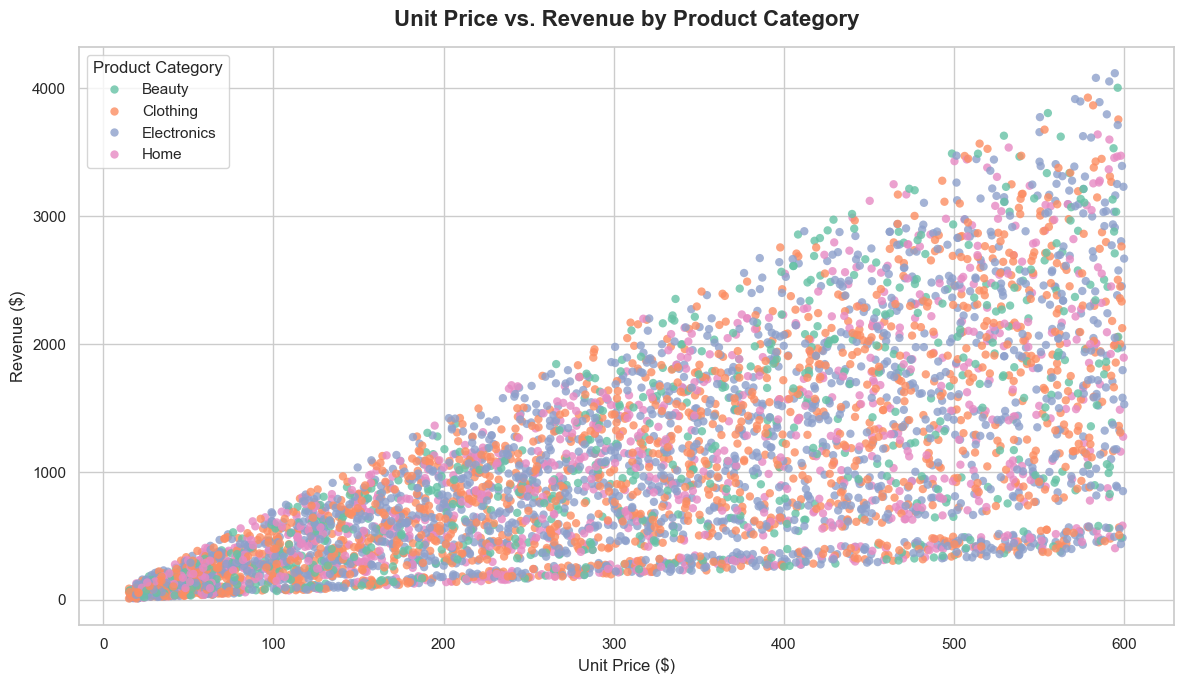

In [8]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='unit_price', y='revenue', hue='product_category', palette='Set2', alpha=0.8, edgecolor='none')
plt.title('Unit Price vs. Revenue by Product Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Unit Price ($)', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(title='Product Category', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('charts/scatter_plot.png', bbox_inches='tight', dpi=300)
plt.show()

### Insight
There is a strong positive correlation ($0.678$) between price and revenue. Transactions containing items with higher unit prices yield higher overall revenue. Furthermore, we can see that all categories are mixed evenly across the unit price range, indicating that price brackets do not differ by product category.

## 11. Additional Visualizations
We create a correlation heatmap of metrics and a boxplot of regional revenue to expand our visual profiling.

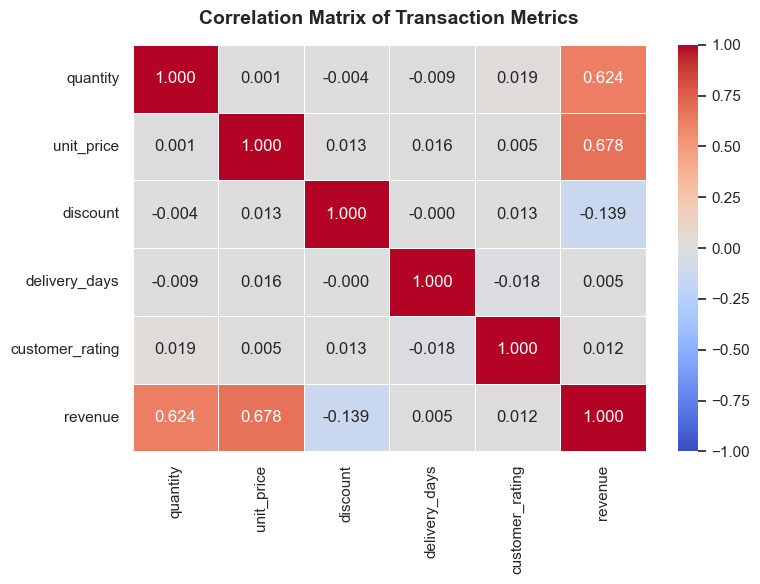

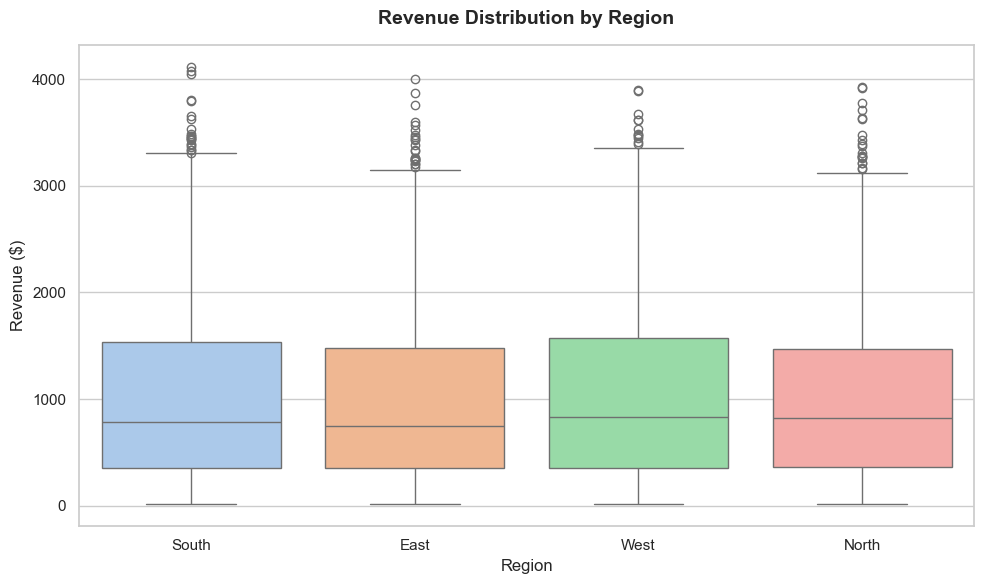

In [9]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ['quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'revenue']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Transaction Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# Regional Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='region', y='revenue', palette='pastel')
plt.title('Revenue Distribution by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.tight_layout()
plt.savefig('charts/regional_revenue_boxplot.png', bbox_inches='tight', dpi=300)
plt.show()

### Insight
- The **Correlation Heatmap** highlights that `revenue` is strongly linked to `unit_price` ($0.678$) and `quantity` ($0.624$). Discounts have a mild negative relation ($-0.139$). Rating and delivery days show zero correlation with sales numbers.
- The **Regional Boxplot** shows that the median and interquartile spread of transaction values are nearly identical across the East, West, North, and South, demonstrating that regional markets behave in a highly uniform manner.

## 12. Dashboard Data Preparation
We prepare the final dataset for Power BI by creating derived columns (Year, Month, Month_Number, Quarter) from order_date and exporting it to dashboard/dashboard_data.csv.

In [10]:
# Copy dataframe and add derived fields
db_df = df.copy()
db_df['Year'] = db_df['order_date'].dt.year
db_df['Month'] = db_df['order_date'].dt.strftime('%B')
db_df['Month_Number'] = db_df['order_date'].dt.month
db_df['Quarter'] = 'Q' + db_df['order_date'].dt.quarter.astype(str)

# Drop unneeded intermediate column
if 'year_month' in db_df.columns:
    db_df = db_df.drop(columns=['year_month'])

# Export dashboard data
db_df.to_csv('dashboard/dashboard_data.csv', index=False)
print("Dashboard data exported to dashboard/dashboard_data.csv successfully.")
print("Columns exported:", db_df.columns.tolist())

Dashboard data exported to dashboard/dashboard_data.csv successfully.
Columns exported: ['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue', 'Year', 'Month', 'Month_Number', 'Quarter']


## 13. Key Visual Insights
1. **Electronics Leads Revenue:** Generated **$1,829,899.22** (35.8% of total revenue) across 1,777 transactions.
2. **Sales are balanced regionally:** West ($1.35M) leads slightly, but all regions generate above $1.2M.
3. **Card payments are standard:** Accounts for **45.4%** of all transactions, followed by COD at 35.5%.
4. **Revenue skewness:** Transaction value has a moderately right-skewed distribution centered around a median of **$796.65** and stretched by large orders up to $4,119.33.
5. **Operational Consistency:** Customer rating (~2.97) and delivery time (~6.12 days) are stable across all categories and regions.
6. **Promotions have no volume effect:** Discount rates show zero correlation ($-0.004$) with quantity ordered, proving that offering higher discounts does not increase transaction order volumes.

## 14. Conclusion
Data visualization reveals that the retail business model is highly stable and uniform. Revenue is primarily driven by unit prices and transaction quantities, while discount rate variance does not translate to customer volume differences. Operational performance is highly standardized across all categories and regions.